# 05 — Decision & Reranking

Inspects `DecisionEngine` (accept/uncertain/reject thresholds + plugin trigger policy) and `Reranker` (multi-evidence fusion across the full Retriever Top-K).

**Evidence approach for this notebook (no guessing):** plugin evidence here is **hand-constructed** to match the exact schema `Reranker` reads (verified directly against `src/decision/reranker.py`: `_extract_ocr_candidates`, `_extract_color_lab`, `_extract_barcode_matches`, `_extract_plugin_confidences`) — not produced by running the real OCR/Color/Barcode backends. That keeps every case here fully controllable and reproducible. Running the real plugins is `06_plugins_deep_dive.ipynb`'s job.

Covered in this notebook:

1. Setup and helpers
2. Load `DecisionEngine`, `Retriever` (optional), `Reranker`
3. `DecisionEngine.evaluate_thresholds()` — accept/uncertain/reject regions
4. `decide()` on a real crop (Detector -> Cropper -> Retriever -> Decide)
5. Synthetic case: `uncertain` trigger
6. Synthetic case: `ambiguous` trigger
7. Synthetic case: `force` trigger (overrides even a confident accept)
8. Plugin evidence schema reference
9. Case study A — barcode evidence flips an incorrect Top-1
10. Case study B — confusable-pair guard downgrades an accepted decision
11. Retrieval-protection boost-ratio sweep (barcode vs OCR vs color)
12. Summary


## 1. Environment setup

(identical boilerplate to `04_retrieval_analysis.ipynb` §1 — `PROJECT_ROOT` resolution, `sys.path`, `os.chdir`)

In [12]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
assert (PROJECT_ROOT / "configs" / "config.yaml").is_file()

Project root: g:\VsCode\Python\DACN\stocktaking_ai_mini


In [13]:
import json
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.core.config import load_config
from src.core.utils import generate_id
from src.detection.detector import Detector
from src.detection.cropper import Cropper
from src.retrieval.retriever import Retriever
from src.decision.decision import DecisionEngine, STATUS_ACCEPTED, STATUS_UNCERTAIN, STATUS_REJECTED
from src.decision.reranker import Reranker
from src.models.models import (
    BoundingBox, ImageData, RefinementResult,
    RetrievalCandidate, RetrievalResult, PluginResult,
)

pd.set_option("display.max_colwidth", 80)
%matplotlib inline

## 2. Config, helpers, DTO builders

In [14]:
config = load_config()

print("--- decision ---")
print(f"similarity_threshold:   {config.decision.similarity_threshold}")
print(f"uncertain_band:         {config.decision.uncertain_band}")
print(f"min_confidence_accept:  {config.decision.min_confidence_accept}")
print(f"detection_weight:       {config.decision.detection_weight}")
print(f"similarity_weight:      {config.decision.similarity_weight}")
print(f"ambiguous_top_n:        {config.decision.ambiguous_top_n}")
print(f"ambiguous_margin:       {config.decision.ambiguous_margin}")
print(f"\nforce_rules:            {config.plugins.force_rules}")
print(f"confusable_pairs:       {config.rerank.confusable_pairs}")
print(f"\nretrieval_protection:   mode={config.rerank.retrieval_protection.consensus_mode}")
print(f"  barcode_strong_ratio: {config.rerank.retrieval_protection.barcode_strong_ratio}")
print(f"  ocr_strong_ratio:     {config.rerank.retrieval_protection.ocr_strong_ratio}")
print(f"  color_strong_ratio:  {config.rerank.retrieval_protection.color_strong_ratio}")

--- decision ---
similarity_threshold:   0.55
uncertain_band:         0.15
min_confidence_accept:  0.6
detection_weight:       0.35
similarity_weight:      0.65
ambiguous_top_n:        3
ambiguous_margin:       0.05

force_rules:            {'5': ['barcode', 'color'], '6': ['barcode', 'color'], '7': ['ocr'], '8': ['ocr']}
confusable_pairs:       [['7', '8']]

retrieval_protection:   mode=hybrid
  barcode_strong_ratio: 1.0
  ocr_strong_ratio:     0.3
  color_strong_ratio:  0.2


Helper functions — build `RetrievalResult`/`PluginResult` DTOs directly, never a plain dict (DTO discipline):

In [15]:
def make_retrieval_result(candidates, detection_confidence=0.9, crop_id=None):
    """Builds a RetrievalResult from (product_id, product_name, similarity_score) tuples."""
    crop_id = crop_id or generate_id(prefix="crop_")
    ranked = [
        RetrievalCandidate(product_id=str(pid), product_name=name, similarity_score=float(score), rank=i + 1)
        for i, (pid, name, score) in enumerate(candidates)
    ]
    return RetrievalResult(crop_id=crop_id, candidates=ranked, detection_confidence=detection_confidence)


def make_plugin_result(crop_id, ocr=None, color=None, barcode=None):
    """Builds a PluginResult whose evidence dicts match the exact schema Reranker reads.
    See src/decision/reranker.py: _extract_ocr_candidates / _extract_color_lab / _extract_barcode_matches.
    """
    evidence, executed = {}, []
    if ocr is not None:
        evidence["ocr"] = ocr
        executed.append("ocr")
    if color is not None:
        evidence["color"] = color
        executed.append("color")
    if barcode is not None:
        evidence["barcode"] = barcode
        executed.append("barcode")
    return PluginResult(crop_id=crop_id, executed_plugins=executed, evidence=evidence)


def rgb_to_opencv_lab(r, g, b):
    """sRGB (0-255) -> OpenCV Lab (L,a,b roughly 0-255), same convention as
    Reranker._load_color_reference uses for data/metadata/product_colors.json."""
    bgr = np.array([[[b, g, r]]], dtype=np.uint8)
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)[0, 0]
    return [float(lab[0]), float(lab[1]), float(lab[2])]


def print_decision(label, decision):
    print(f"{label}: product_id={decision.product_id}  status={decision.status}  "
          f"final_confidence={decision.final_confidence:.3f}")
    print(f"  needs_plugin={decision.needs_plugin}  trigger_reasons={sorted(decision.trigger_reasons)}  "
          f"forced_plugins={sorted(decision.forced_plugins)}")
    print(f"  reason: {decision.reason}")

## 3. Load `DecisionEngine`, `Retriever` (optional), `Reranker`

`DecisionEngine` never touches AI models, so it always loads. `Retriever` is optional here (only needed for real product lookups / a live crop in §4, §9, §10) — reuse the same build-if-missing pattern as `04_retrieval_analysis.ipynb` §2.

In [16]:
decision_engine = DecisionEngine(config)

RUN_BUILD_IF_MISSING = True
try:
    retriever = Retriever(config)
    print(f"Retriever loaded. Gallery size: {retriever._index.ntotal} vectors.")
except FileNotFoundError as exc:
    print(f"Retriever could not be loaded: {exc}")
    retriever = None
    if RUN_BUILD_IF_MISSING:
        from src.pipeline.build import BuildPipeline
        build_config = config.model_copy(update={
            "catalog": config.catalog.model_copy(update={"build_metadata": True}),
            "retrieval": config.retrieval.model_copy(update={"build_gallery_index": True}),
        })
        BuildPipeline(build_config).run()
        retriever = Retriever(config)
        print(f"Build complete. Gallery size: {retriever._index.ntotal} vectors.")

product_lookup = retriever.get_product if retriever is not None else (lambda pid: None)
reranker = Reranker(config, decision_engine, product_lookup)

2026-09-04 01:57:32 | INFO     | src.decision.decision | DecisionEngine initialized with similarity_threshold=0.55 min_confidence_accept=0.60 uncertain_band=0.15 ambiguous_top_n=3 ambiguous_margin=0.05 force_rules=4
2026-09-04 01:57:32 | INFO     | src.decision.decision | DecisionEngine force_rules content: {'5': frozenset({'color', 'barcode'}), '6': frozenset({'color', 'barcode'}), '7': frozenset({'ocr'}), '8': frozenset({'ocr'})}
2026-09-04 01:57:32 | INFO     | src.retrieval.backends.siglip2 | Loading SigLIP2 model 'google/siglip2-base-patch16-224' on device='cuda' dtype='torch.float16'


Loading weights: 100%|██████████| 408/408 [00:04<00:00, 96.12it/s]


2026-09-04 01:57:52 | INFO     | src.retrieval.backends.siglip2 | SigLIP2 CUDA memory after load: allocated=1.67 GB reserved=1.70 GB
2026-09-04 01:57:52 | INFO     | src.retrieval.backends.siglip2 | Siglip2Backend initialized (model_name='google/siglip2-base-patch16-224', device='cuda', dtype='torch.float16')
2026-09-04 01:57:52 | INFO     | src.retrieval.retriever | Loading gallery FAISS index from 'G:\VsCode\Python\DACN\stocktaking_ai_mini\data\cache\gallery_index.faiss'.
2026-09-04 01:57:52 | INFO     | src.retrieval.retriever | Loading gallery metadata from 'G:\VsCode\Python\DACN\stocktaking_ai_mini\data\cache\gallery_metadata.json'.
2026-09-04 01:57:52 | INFO     | src.retrieval.retriever | Loading product catalog from 'G:\VsCode\Python\DACN\stocktaking_ai_mini\data\metadata\products.json'.
2026-09-04 01:57:52 | INFO     | src.retrieval.retriever | Loaded 21 product(s) from catalog.
2026-09-04 01:57:52 | INFO     | src.retrieval.retriever | Retriever initialized with backend='sigl

Inspect the **real** product schema instead of assuming its shape:

In [17]:
if retriever is not None and config.plugins.force_rules:
    sample_pid = next(iter(config.plugins.force_rules))
    product = retriever.get_product(sample_pid)
    print(f"retriever.get_product('{sample_pid}') ->")
    print(product)

retriever.get_product('5') ->
{'product_id': '5', 'product_name': 'Phấn mắt hồng nhạt (BE203) ', 'brand': '', 'category': '', 'barcode': '4909978992293', 'description': '', 'folder': 'マジョリカマジョルカ シャドーカスタマイズ (BE203) ', 'image_count': 21}


## 4. `DecisionEngine.evaluate_thresholds()` — accept/uncertain/reject regions

`evaluate_thresholds()` is pure (reads only config) — sweep similarity at a fixed detection confidence and see exactly where each region lies. Note from the source: `accepted` requires **both** `similarity >= similarity_threshold` **and** `final_confidence >= min_confidence_accept` — a high-similarity candidate can still land in `uncertain` if `final_confidence` (which also depends on `detection_confidence`) falls short.

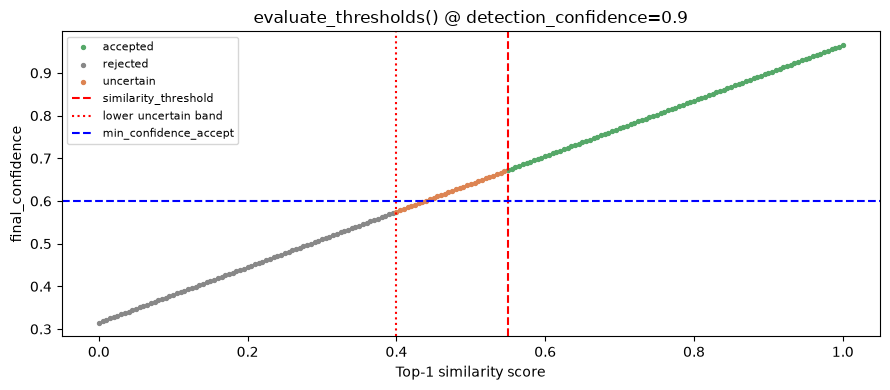

In [18]:
similarities = np.linspace(0.0, 1.0, 201)
fixed_detection_confidence = 0.9

rows = [
    {"similarity": s, **dict(zip(("status", "final_confidence"),
                                  decision_engine.evaluate_thresholds(s, fixed_detection_confidence)))}
    for s in similarities
]
threshold_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
color_map = {STATUS_ACCEPTED: "#55A868", STATUS_UNCERTAIN: "#DD8452", STATUS_REJECTED: "#888888"}
for status, group in threshold_df.groupby("status"):
    ax.scatter(group["similarity"], group["final_confidence"], s=8, color=color_map[status], label=status)

ax.axvline(config.decision.similarity_threshold, color="red", linestyle="--", label="similarity_threshold")
ax.axvline(config.decision.similarity_threshold - config.decision.uncertain_band,
           color="red", linestyle=":", label="lower uncertain band")
ax.axhline(config.decision.min_confidence_accept, color="blue", linestyle="--", label="min_confidence_accept")
ax.set_xlabel("Top-1 similarity score")
ax.set_ylabel("final_confidence")
ax.set_title(f"evaluate_thresholds() @ detection_confidence={fixed_detection_confidence}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. `decide()` on a real crop

Runs the same upstream chain as `04_retrieval_analysis.ipynb` §4 (Detector -> Cropper -> Retriever), then feeds the real `RetrievalResult` into `decide()`.

In [19]:
if retriever is not None:
    benchmark_images_dir = config.resolve_path(config.paths.benchmark_images_dir)
    query_dir = config.resolve_path(config.paths.query_dir)
    candidate_dir = benchmark_images_dir if benchmark_images_dir.exists() and any(
        benchmark_images_dir.iterdir()
    ) else query_dir
    IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    available_images = sorted([f for f in candidate_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS])

    def load_image_data(image_path):
        data = np.fromfile(str(image_path), dtype=np.uint8)
        image_array = cv2.imdecode(data, cv2.IMREAD_COLOR)
        height, width = image_array.shape[:2]
        return ImageData(image_id=image_path.stem, source_path=str(image_path),
                          image_array=image_array, width=width, height=height)

    detector = Detector(config)
    cropper = Cropper(config)
    empty_refinement = lambda image_id: RefinementResult(image_id=image_id, triggered=False, backend="none")

    sample_path = random.choice(available_images)
    sample_image = load_image_data(sample_path)
    sample_crops = cropper.crop(sample_image, detector.detect(sample_image), empty_refinement(sample_image.image_id))
    assert sample_crops, "No crops produced — pick a different image."

    real_retrieval_result = retriever.retrieve(sample_crops[0])
    real_decision = decision_engine.decide(real_retrieval_result)
    print(f"Sample image: {sample_path.name}")
    print_decision("Real decision", real_decision)
else:
    print("Retriever not available — skip.")

2026-09-04 01:57:53 | INFO     | src.detection.backends.rf_detr | Loading RF-DETR model class='RFDETRBase' kwargs={'pretrain_weights': 'weights/detector/checkpoint_best_ema.pth'}


[2026-09-04 01:57:53] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.
[2026-09-04 01:57:53] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


2026-09-04 01:57:53 | INFO     | src.detection.backends.rf_detr | Optimizing RF-DETR for inference (dtype=float32 compile=False batch_size=1)
2026-09-04 01:57:54 | INFO     | src.detection.backends.rf_detr | RfDetrBackend initialized (variant='base' weights_path='weights/detector/checkpoint_best_ema.pth')
2026-09-04 01:57:54 | INFO     | src.detection.detector | Detector initialized with backend='rf_detr'
2026-09-04 01:57:54 | INFO     | src.detection.cropper | Cropper initialized with padding=4px target_size=(1024, 1024) use_refined_bbox=True
2026-09-04 01:57:54 | INFO     | src.detection.detector | Detector found 7 region(s) in image_id='IMG_0569_jpg.rf.cDK0vyv3sXtlEyBdiQPz' (474.66 ms)
2026-09-04 01:57:54 | INFO     | src.detection.cropper | Cropper produced 7 crop(s) for image_id='IMG_0569_jpg.rf.cDK0vyv3sXtlEyBdiQPz' (16.43 ms)
2026-09-04 01:57:54 | INFO     | src.retrieval.backends.siglip2 | SigLIP2 input: shape=(1, 3, 224, 224) dtype=torch.float32
2026-09-04 01:57:54 | INFO     

## 6. Synthetic case: `uncertain` trigger

Places the Top-1 similarity exactly in the middle of `[similarity_threshold - uncertain_band, similarity_threshold)`.

In [20]:
lower_band = config.decision.similarity_threshold - config.decision.uncertain_band
mid_uncertain = (lower_band + config.decision.similarity_threshold) / 2

rr_uncertain = make_retrieval_result([("9001", "Sample Product A", mid_uncertain)], detection_confidence=0.9)
decision_uncertain = decision_engine.decide(rr_uncertain)
print_decision("Uncertain-band case", decision_uncertain)
assert decision_uncertain.status == STATUS_UNCERTAIN
assert "uncertain" in decision_uncertain.trigger_reasons

2026-09-04 01:57:54 | INFO     | src.decision.decision | DecisionEngine requests plugin evidence for crop_id='crop_9aebc1710c4c': reasons=['uncertain'] forced_plugins=[]
2026-09-04 01:57:54 | INFO     | src.decision.decision | DecisionEngine resolved crop_id='crop_9aebc1710c4c' -> status='uncertain' final_confidence=0.624 (0.03 ms)
Uncertain-band case: product_id=9001  status=uncertain  final_confidence=0.624
  needs_plugin=True  trigger_reasons=['uncertain']  forced_plugins=[]
  reason: similarity 0.475 in uncertain band [0.400, 0.550)


## 7. Synthetic case: `ambiguous` trigger

Builds `ambiguous_top_n` candidates, all comfortably above `similarity_threshold` on their own, whose spread is `<= ambiguous_margin` — similarity alone can't separate them even though none of them is individually uncertain.

In [21]:
top_n = config.decision.ambiguous_top_n
margin = config.decision.ambiguous_margin - 1e-6
base_score = config.decision.similarity_threshold + 0.5
close_scores = [base_score - i * (margin / max(top_n - 1, 1)) for i in range(top_n)]

rr_ambiguous = make_retrieval_result(
    [(f"910{i}", f"Look-alike Variant {i}", score) for i, score in enumerate(close_scores)],
    detection_confidence=0.9,
)
decision_ambiguous = decision_engine.decide(rr_ambiguous)
print(f"Candidate scores: {[round(s, 4) for s in close_scores]}")
print_decision("Ambiguous case", decision_ambiguous)
assert "ambiguous" in decision_ambiguous.trigger_reasons

2026-09-04 01:57:54 | INFO     | src.decision.decision | DecisionEngine requests plugin evidence for crop_id='crop_c9d6f5aa8f20': reasons=['ambiguous'] forced_plugins=[]
2026-09-04 01:57:54 | INFO     | src.decision.decision | DecisionEngine resolved crop_id='crop_c9d6f5aa8f20' -> status='accepted' final_confidence=0.998 (0.03 ms)
Candidate scores: [1.05, 1.025, 1.0]
Ambiguous case: product_id=9100  status=accepted  final_confidence=0.998
  needs_plugin=True  trigger_reasons=['ambiguous']  forced_plugins=[]
  reason: top-3 spread <= 0.050


## 8. Synthetic case: `force` trigger — overrides even a confident accept

Picks a real `product_id` from `plugins.force_rules` and gives it a very high similarity score. Since `force` is one of three *independent* trigger reasons, `needs_plugin` stays `True` even though the decision is already `accepted` on similarity alone.

In [22]:
forced_pid = next(iter(config.plugins.force_rules))
print(f"product_id=\'{forced_pid}\' forces plugins={config.plugins.force_rules[forced_pid]}")

rr_force = make_retrieval_result(
    [(forced_pid, "Forced-rule product", config.decision.similarity_threshold + 0.20)],
    detection_confidence=0.9,
)
decision_force = decision_engine.decide(rr_force)
print_decision("Force-rule case", decision_force)
assert decision_force.status == STATUS_ACCEPTED
assert decision_force.needs_plugin  # forced despite already being confidently accepted

product_id='5' forces plugins=['barcode', 'color']
2026-09-04 01:57:54 | INFO     | src.decision.decision | DecisionEngine requests plugin evidence for crop_id='crop_0a14fd091378': reasons=['force'] forced_plugins=['barcode', 'color']
2026-09-04 01:57:54 | INFO     | src.decision.decision | DecisionEngine resolved crop_id='crop_0a14fd091378' -> status='accepted' final_confidence=0.802 (0.03 ms)
Force-rule case: product_id=5  status=accepted  final_confidence=0.802
  needs_plugin=True  trigger_reasons=['force']  forced_plugins=['barcode', 'color']
  reason: forced plugins ['barcode', 'color']


## 9. Plugin evidence schema reference

Exact shape `Reranker` reads from `PluginResult.evidence` (verified against `src/decision/reranker.py`):

| Plugin | `evidence[...]` key | Fields actually read |
|---|---|---|
| OCR | `"ocr"` | `orientation_candidates: [{rotation, text, score, confidence, information_score, ...}]` (or a flat `text`/`confidence` fallback), plus a top-level `confidence` |
| Color | `"color"` | `representative_lab: [L, a, b]` (OpenCV Lab scale), `confidence` |
| Barcode | `"barcode"` | `barcodes: [{data: str}, ...]`, `confidence`, optional `preprocessing_stage` |

## 10. Case study A — barcode evidence flips an incorrect Top-1

Picks two **real** products from the gallery — one with a non-empty catalog `barcode` field (found by inspecting live data, not assumed) — and shows the wrong visual Top-1 getting overturned by an exact barcode match.

In [23]:
def find_product_with_barcode(product_ids):
    for pid in product_ids:
        product = retriever.get_product(pid)
        if product and str(product.get("barcode", "")).strip():
            return pid, product
    return None, None

if retriever is not None:
    gallery_metadata_path = config.resolve_path(config.retrieval.gallery_metadata_path)
    with open(gallery_metadata_path, "r", encoding="utf-8") as f:
        gallery_metadata_05 = json.load(f)
    candidate_ids = sorted({str(e["product_id"]) for e in gallery_metadata_05})

    correct_id, correct_product = find_product_with_barcode(candidate_ids)
    if correct_id is None:
        print("No product with a non-empty catalog barcode found — skipping this case study.")
    else:
        wrong_id = next(pid for pid in candidate_ids if pid != correct_id)
        wrong_product = retriever.get_product(wrong_id)
        wrong_name = wrong_product.get("product_name", wrong_product.get("name", wrong_id))
        correct_name = correct_product.get("product_name", correct_product.get("name", correct_id))

        wrong_score = config.decision.similarity_threshold + 0.05
        correct_score = config.decision.similarity_threshold - 0.02

        rr_barcode_case = make_retrieval_result(
            [(wrong_id, wrong_name, wrong_score), (correct_id, correct_name, correct_score)],
            detection_confidence=0.9,
        )

        preliminary = decision_engine.decide(rr_barcode_case)
        print_decision("Preliminary (visual retrieval only)", preliminary)

        plugin_result_barcode = make_plugin_result(
            rr_barcode_case.crop_id,
            barcode={"barcodes": [{"data": correct_product["barcode"]}], "confidence": 0.95},
        )
        final_barcode_case = reranker.rerank(rr_barcode_case, plugin_result_barcode)
        print_decision("\nFinal (after barcode fusion)", final_barcode_case)

        display(pd.DataFrame(final_barcode_case.rerank_debug["candidates"]))
else:
    print("Retriever not available — skip.")

2026-09-04 01:57:54 | INFO     | src.decision.decision | DecisionEngine resolved crop_id='crop_e261f02c12ad' -> status='accepted' final_confidence=0.705 (0.03 ms)
Preliminary (visual retrieval only): product_id=13  status=accepted  final_confidence=0.705
  needs_plugin=False  trigger_reasons=[]  forced_plugins=[]
  reason: similarity 0.600 and final confidence 0.705 meet acceptance thresholds.
2026-09-04 01:57:54 | INFO     | src.decision.reranker | Reranker finalized crop_id='crop_e261f02c12ad' -> product_id=1 status='accepted' final_confidence=1.000 retrieval_consensus=0.5 consensus_winner=13 (2.92 ms)

Final (after barcode fusion): product_id=1  status=accepted  final_confidence=1.000
  needs_plugin=False  trigger_reasons=[]  forced_plugins=[]
  reason: Reranked using plugin evidence plugins=['barcode']. Exact barcode match (effective_boost=0.9500). Upgraded to accepted after evidence fusion.


,product_id,base_similarity,barcode_boost,ocr_boost,color_boost,barcode_match_strength,ocr_match_strength,color_match_strength,barcode_plugin_confidence,ocr_plugin_confidence,...,ocr_orientation_match_candidates,barcode_plugin_weight,ocr_plugin_weight,color_plugin_weight,barcode_retrieval_ratio,ocr_retrieval_ratio,color_retrieval_ratio,adjusted_score,color_code,delta_e
0,1,0.53,0.95,0.0,0.0,1.0,0.0,0.0,0.95,0.0,...,[],1.0,0.6,0.2,1.0,0.675079,0.628662,1.48,None,None
1,13,0.60,0.00,0.0,0.0,0.0,0.0,0.0,0.95,0.0,...,[],1.0,0.6,0.2,1.0,1.000000,1.000000,0.60,None,None


> `config.rerank.retrieval_protection.barcode_strong_ratio = 1.00` vs `ocr_strong_ratio = 0.30` and `color_strong_ratio = 0.20` — the config itself encodes a deliberate trust hierarchy: an exact barcode match is allowed to override retrieval consensus almost fully, while OCR/color evidence is discounted much more heavily when it disagrees with the crowd.

## 11. Case study B — confusable-pair guard downgrades an accepted decision

Uses `config.rerank.confusable_pairs` directly (no hardcoded ids) and real catalog tokens (via `Reranker._extract_catalog_tokens`, same private-attribute-introspection convention already used on `retriever._index` in notebook 04) to build OCR text that favors the *other* member of the pair. Similarity scores are chosen so the winner does **not** switch — isolating the guard's effect on `status` alone.

In [24]:
if not config.rerank.confusable_pairs:
    print("No confusable pairs configured — skipping this case study.")
else:
    id_a, id_b = (str(x) for x in config.rerank.confusable_pairs[0])

    def resolve_name(pid):
        if retriever is not None:
            p = retriever.get_product(pid)
            if p:
                return p.get("product_name", p.get("name", pid))
        return config.catalog.id_mapping.get(pid, pid)

    name_a, name_b = resolve_name(id_a), resolve_name(id_b)
    tokens_b = reranker._extract_catalog_tokens(name_b)
    ocr_text_favoring_b = tokens_b[0] if tokens_b else name_b
    print(f"Confusable pair: {id_a} (\'{name_a}\')  <->  {id_b} (\'{name_b}\')")
    print(f"OCR text used (favors \'{id_b}\'): \'{ocr_text_favoring_b}\'")

    score_a = 0.98
    score_b = config.decision.similarity_threshold

    rr_confusable = make_retrieval_result([(id_a, name_a, score_a), (id_b, name_b, score_b)], detection_confidence=0.9)

    preliminary_conf = decision_engine.decide(rr_confusable)
    print_decision("\nPreliminary", preliminary_conf)

    plugin_result_confusable = make_plugin_result(
        rr_confusable.crop_id,
        ocr={"orientation_candidates": [
            {"rotation": 0, "text": ocr_text_favoring_b, "score": 0.9, "confidence": 0.9, "information_score": 0.8}
        ], "confidence": 0.9},
    )
    final_confusable = reranker.rerank(rr_confusable, plugin_result_confusable)
    print_decision("\nFinal", final_confusable)
    conflict_detected = final_confusable.rerank_debug["confusable_conflict_detected"]
    print(f"confusable_conflict_detected: {conflict_detected}")

    display(pd.DataFrame(final_confusable.rerank_debug["candidates"])[
        ["product_id", "base_similarity", "ocr_match_strength", "ocr_boost", "adjusted_score"]
    ])

Confusable pair: 7 ('Kem ABA')  <->  8 ('Kem ABC')
OCR text used (favors '8'): 'KEM'
2026-09-04 01:57:54 | INFO     | src.decision.decision | DecisionEngine requests plugin evidence for crop_id='crop_e0fd38c197b4': reasons=['force'] forced_plugins=['ocr']
2026-09-04 01:57:54 | INFO     | src.decision.decision | DecisionEngine resolved crop_id='crop_e0fd38c197b4' -> status='accepted' final_confidence=0.952 (0.03 ms)

Preliminary: product_id=7  status=accepted  final_confidence=0.952
  needs_plugin=True  trigger_reasons=['force']  forced_plugins=['ocr']
  reason: forced plugins ['ocr']
2026-09-04 01:57:54 | INFO     | src.decision.reranker | Reranker finalized crop_id='crop_e0fd38c197b4' -> product_id=7 status='accepted' final_confidence=1.000 retrieval_consensus=0.5 consensus_winner=7 (0.34 ms)

Final: product_id=7  status=accepted  final_confidence=1.000
  needs_plugin=False  trigger_reasons=[]  forced_plugins=[]
  reason: Reranked using plugin evidence plugins=['ocr']. OCR matched cat

,product_id,base_similarity,ocr_match_strength,ocr_boost,adjusted_score
0,7,0.98,1.0,0.540000,1.520000
1,8,0.55,1.0,0.285166,0.835166


## 12. Retrieval-protection boost-ratio sweep

Sweeps `protection_strength` through `Reranker._plugin_boost_ratio()` directly for a non-consensus-winner candidate, visualizing the exact hierarchy each `*_strong_ratio` config value encodes.

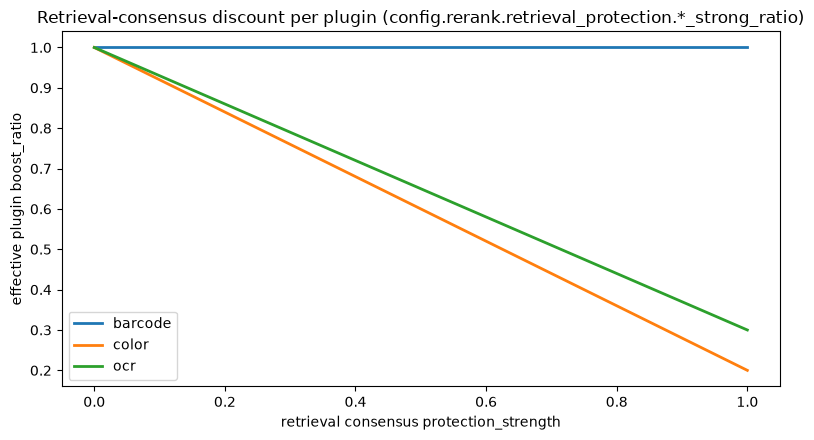

In [25]:
protection_strengths = np.linspace(0, 1, 50)
rows = []
for ps in protection_strengths:
    guard = {"available": True, "consensus_winner": "OTHER_PRODUCT", "protection_strength": ps}
    for plugin_name in ("barcode", "ocr", "color"):
        rows.append({
            "protection_strength": ps,
            "plugin": plugin_name,
            "boost_ratio": reranker._plugin_boost_ratio("NOT_WINNER", guard, plugin_name),
        })
ratio_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
for plugin_name, group in ratio_df.groupby("plugin"):
    ax.plot(group["protection_strength"], group["boost_ratio"], label=plugin_name, linewidth=2)
ax.set_xlabel("retrieval consensus protection_strength")
ax.set_ylabel("effective plugin boost_ratio")
ax.set_title("Retrieval-consensus discount per plugin (config.rerank.retrieval_protection.*_strong_ratio)")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Summary

In [26]:
summary = {
    "Uncertain-band case (\u00a76) status": decision_uncertain.status,
    "Ambiguous case (\u00a77) triggered": "ambiguous" in decision_ambiguous.trigger_reasons,
    "Force-rule case (\u00a78) needs_plugin despite accepted": decision_force.needs_plugin,
    "Confusable guard triggered (\u00a711)": final_confusable.rerank_debug["confusable_conflict_detected"]
        if "final_confusable" in dir() else "n/a",
}
pd.DataFrame([summary]).T.rename(columns={0: "Value"})

,Value
Uncertain-band case (§6) status,uncertain
Ambiguous case (§7) triggered,True
Force-rule case (§8) needs_plugin despite accepted,True
Confusable guard triggered (§11),False


---
**Quick observations (fill in after running):**

- In §4, is there a visible band where `similarity >= similarity_threshold` but `status != accepted`? That's `min_confidence_accept` binding through `detection_weight`/`similarity_weight`, not the similarity threshold itself.
- In §5, did the real crop's `trigger_reasons` match your expectation given its Top-K spread?
- In §12, how much does `color`'s curve flatten out compared to `barcode`'s as `protection_strength` grows? That gap is exactly how much retrieval consensus is allowed to override each plugin in this system.
- Are there other `force_rules` product pairs besides the configured `confusable_pairs` that might deserve the same guard?

**Next notebook:** `06_plugins_deep_dive.ipynb` — running the real OCR (multi-orientation + CLAHE), Color (Lab + CIEDE2000), and Barcode (9-stage decode) plugins on actual crops, to see whether the evidence they produce in practice matches the schemas hand-built here.